# 5. Random Forests 

---

> **Random Forests**: Ähnelt Bagging, aber Zufälligkeit wird auch in den Features eingeführt, nicht nur in den Daten → Bäume werden vielfältiger, Korrelation $\rho$ sinkt

## 5.1 Motivation 

* Bagging mittelt viele Bäume – das reduziert Varianz
* Aber: Wenn die Bäume stark korreliert sind (gleiche dominierende Splits),
bleibt die Varianzreduktion begrenzt
* Ursache: alle Modelle sehen ähnliche Merkmale und lernen ähnliche
Strukturen

> **Merke**: Für Bagging (sowie) Random Forests gilt *Mittelung reduziert Varianz*

* Grundprinzip: 
1. Für jeden Baum: Ziehe ein Bootstrap-Sample der Trainingsdaten
2. Bei jedem Split: Wähle nur aus einer zufälligen Teilmenge von Merkmalen
(max_features)
3. Aggregiere die Vorhersagen aller Bäume (Mittelwert / Mehrheitsvotum)

---
## 5.2 Recap

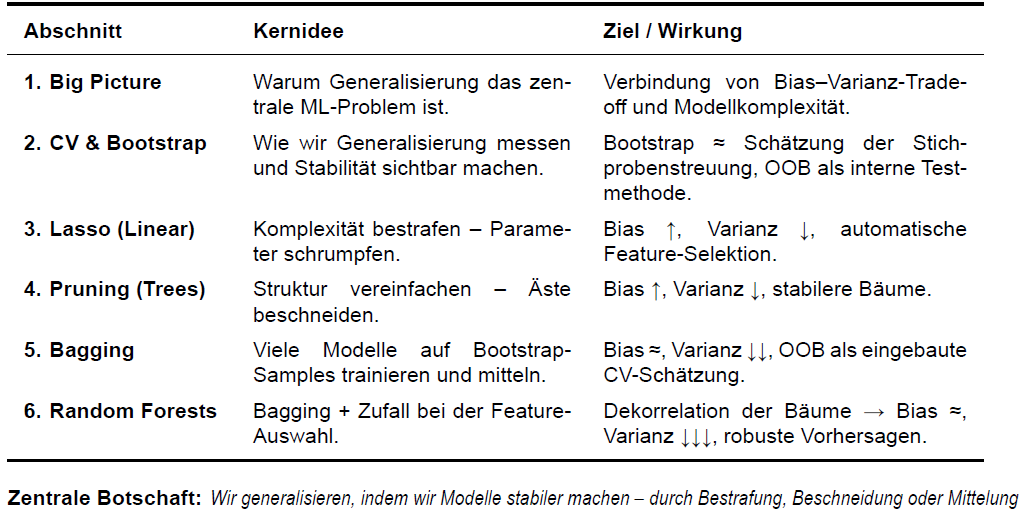

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

In [3]:
# Plot-Styling
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)

In [4]:
# Datensatz laden und vorbereiten (Titanic)
titanic = sns.load_dataset("titanic")
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df = titanic[features + ["survived"]].dropna()
df = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True)

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train-Form: {X_train.shape}, Test-Form: {X_test.shape}")
X_train.head()

Train-Form: (534, 8), Test-Form: (178, 8)


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
44,3,19.0,0,0,7.8792,False,True,False
27,1,19.0,3,2,263.0000,True,False,True
72,2,21.0,0,0,73.5000,True,False,True
685,2,25.0,1,2,41.5792,True,False,False
370,1,25.0,1,0,55.4417,True,False,False


---

## 5.3 Baseline-Vergleich: Single Tree vs. Bagging vs. Random Forest
Wir vergleichen nun drei Modellgenerationen auf denselben Daten:

* Einzelner Decision Tree (hohe Varianz, overfittet leicht)
* Bagging (Mittelung über unbeschränkte Bäume)
* Random Forest (Mittelung über dekorrelierte Bäume)

In [5]:
#  1. Einzelner Decision Tree (voll ausgewachsen)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
acc_tree = tree.score(X_test, y_test)

In [6]:
# 2. Bagging Classifier (100 Bäume)
bagging = BaggingClassifier(
estimator=DecisionTreeClassifier(),
n_estimators=100,
random_state=42
)
bagging.fit(X_train, y_train)
acc_bagging = bagging.score(X_test, y_test)

In [7]:
# 3. Random Forest Classifier (100 Bäume)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
acc_rf = rf.score(X_test, y_test)

,Modell,Test Accuracy
0,Decision Tree,0.747191
1,Bagging,0.752809
2,Random Forest,0.764045


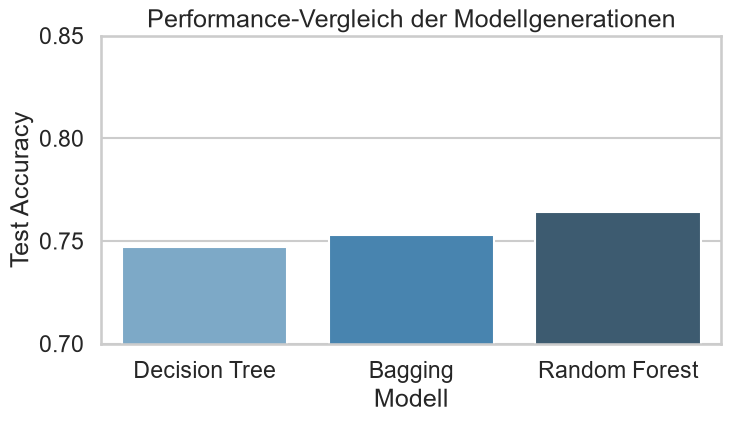

In [10]:
# Ergebnisse zusammenfassen
results_bs = pd.DataFrame({
"Modell": ["Decision Tree", "Bagging", "Random Forest"],
"Test Accuracy": [acc_tree, acc_bagging, acc_rf]
})

display(results_bs)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=results_bs,
    x="Modell",
    y="Test Accuracy",
    hue="Modell",
    palette="Blues_d",
    legend=False
)
plt.ylim(0.7, 0.85)
plt.title("Performance-Vergleich der Modellgenerationen")
plt.show()

**Frage:**
Warum ist der Random Forest in der Regel noch etwas besser oder stabiler als Bagging, obwohl beide 100 Bäume auf Bootstrap-Samples mitteln?

---

## 5.4 Deep Dive: Wie Feature Randomness die Bäume dekorreliert
Um zu verstehen, warum ein Random Forest funktioniert, schauen wir uns das Innere der Ensembles an.
Wir untersuchen: Welches Feature wird im obersten Knoten (Root-Node) der Bäume gewählt?

In [11]:
# Root-Features bei Bagging extrahieren
bagging_roots = [e.tree_.feature[0] for e in bagging.estimators_]
bagging_root_names = [X.columns[i] for i in bagging_roots]

In [12]:
# Root-Features bei Random Forest extrahieren
rf_roots = [e.tree_.feature[0] for e in rf.estimators_]
rf_root_names = [X.columns[i] for i in rf_roots]

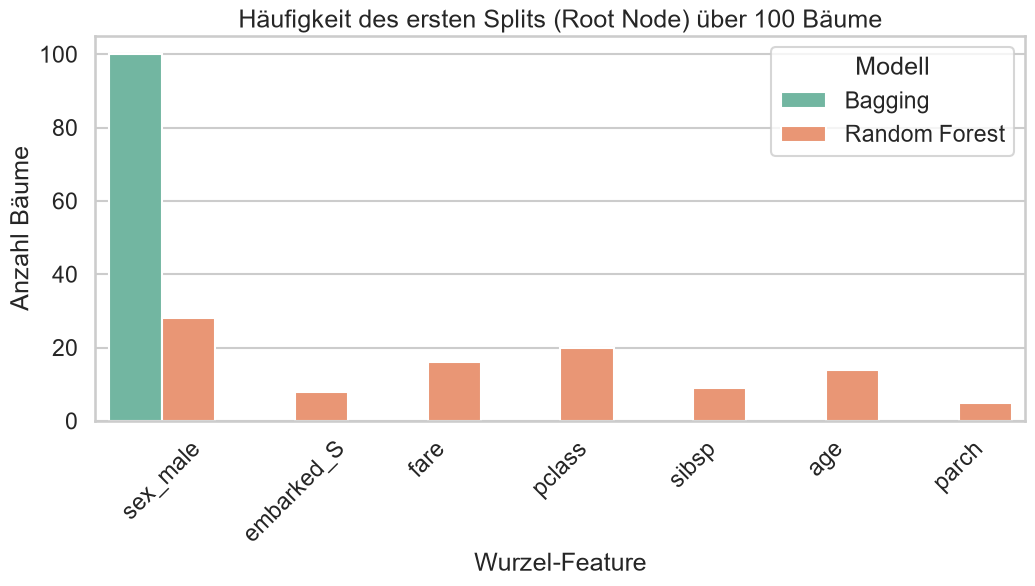

In [13]:
# DataFrames für den Plot  
df_roots = pd.DataFrame({
"Feature": bagging_root_names + rf_root_names,
"Modell": ["Bagging"] * 100 + ["Random Forest"] * 100
})  

plt.figure(figsize=(12, 5))
sns.countplot(data=df_roots, x="Feature", hue="Modell", palette="Set2")
plt.title("Häufigkeit des ersten Splits (Root Node) über 100 Bäume")
plt.xlabel("Wurzel-Feature")
plt.ylabel("Anzahl Bäume")
plt.xticks(rotation=45)
plt.show()

### Beobachtung
Beim Bagging wählt fast jeder Baum dasselbe dominante Feature für den ersten Split. Die Bäume ähneln sich stark.

Beim Random Forest variieren die Wurzel-Features deutlich häufiger, weil in einigen Bäumen das primäre Feature gar nicht zur Auswahl steht.

### Aufgabe

Was bedeutet `max_features="sqrt"` bei der Initialisierung von Scikit-Learns `RandomForestClassifier`? Bei $p = 9$ Features: Wie viele Features darf ein Baum im Random Forest pro Split zufällig betrachten?

---

## 5.5 Hyperparameter-Tuning: 

Die zwei wichtigsten Stellschrauben im Random Forest sind:

* `n_estimators`: Anzahl der Bäume im Ensemble (Mehr ist besser, konvergiert irgendwann).
* `max_features`: Anzahl der pro Split zufällig gezogenen Features ($m$).

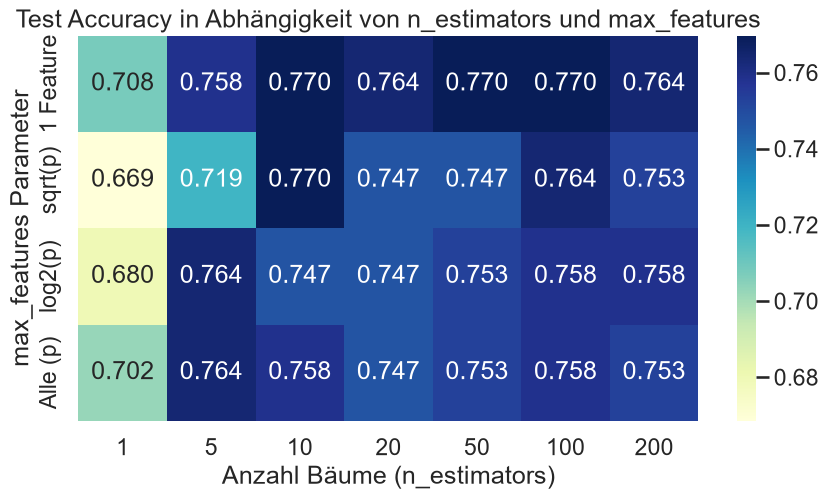

In [14]:
max_feat_options = [1, "sqrt", "log2", None]
n_trees = [1, 5, 10, 20, 50, 100, 200]

heatmap_data = np.zeros((len(max_feat_options), len(n_trees)))

for i, mf in enumerate(max_feat_options):
    for j, n in enumerate(n_trees):
        rf_temp = RandomForestClassifier(n_estimators=n, max_features=mf, random_state=42)
        rf_temp.fit(X_train, y_train)
        heatmap_data[i, j] = rf_temp.score(X_test, y_test)

df_heatmap = pd.DataFrame(
heatmap_data,
index=["1 Feature", "sqrt(p)", "log2(p)", "Alle (p)"],
columns=n_trees
)

plt.figure(figsize=(10, 5))
sns.heatmap(df_heatmap, annot=True, fmt=".3f", cmap="YlGnBu")
plt.xlabel("Anzahl Bäume (n_estimators)")
plt.ylabel("max_features Parameter")
plt.title("Test Accuracy in Abhängigkeit von n_estimators und max_features")
plt.show()

### Beobachtung & Fragen
Was passiert mit der Accuracy, wenn `n_estimators` erhöht wird? Kann ein Random Forest durch zu viele Bäume überanpassen (Overfitting)?

Was passiert, wenn max_features=1 eingestellt ist (extrem starke Einschränkung)?

---

## 5.6 Out-of-Bag (OOB) Evaluation in der Praxis
Wie beim Bagging müssen wir für die Evaluierung eines Random Forests keine explizite Cross-Validation oder ein separates Validation-Set opfern: Wir nutzen die Out-of-Bag (OOB) Daten.

In [15]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB-Score (Trainingsphase):  {rf_oob.oob_score_:.4f}")
print(f"Test-Accuracy (Testdaten):    {rf_oob.score(X_test, y_test):.4f}")

OOB-Score (Trainingsphase):  0.8090
Test-Accuracy (Testdaten):    0.7528


Der OOB-Score ist eine sehr verlässliche, kostenlose Fehlerschätzung direkt aus dem Trainingsprozess!

---

## 5.7 Interpretierbarkeit: Gini Importance vs. Permutation Importance
Random Forests bieten integrierte Feature Importances (Standard: Mean Decrease in Impurity / Gini Importance).
Allerdings hat die Standard-Gini-Importance eine gefährliche Schwachstelle: Sie bevorzugt hoch-kardinale (stetige/viele eindeutige Werte) Merkmale und Rausch-Variablen!

Wir demonstrieren dieses Problem, indem wir eine reine Zufallsvariable (random_noise) zum Datensatz hinzufügen.

In [16]:
# 1. Rausch-Feature zum Datensatz hinzufügen
X_train_noise = X_train.copy()
X_test_noise = X_test.copy()

np.random.seed(42)
X_train_noise["random_noise"] = np.random.randn(len(X_train))
X_test_noise["random_noise"] = np.random.randn(len(X_test))

In [17]:
# 2. Random Forest trainieren
rf_noise = RandomForestClassifier(n_estimators=100, random_state=42)
rf_noise.fit(X_train_noise, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [18]:
# 3a. Standard Gini Importance (MDI)
gini_imp = pd.Series(rf_noise.feature_importances_, index=X_train_noise.columns)

# 3b. Permutation Importance auf den Testdaten berechnen
perm_result = permutation_importance(rf_noise, X_test_noise, y_test, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm_result.importances_mean, index=X_train_noise.columns)

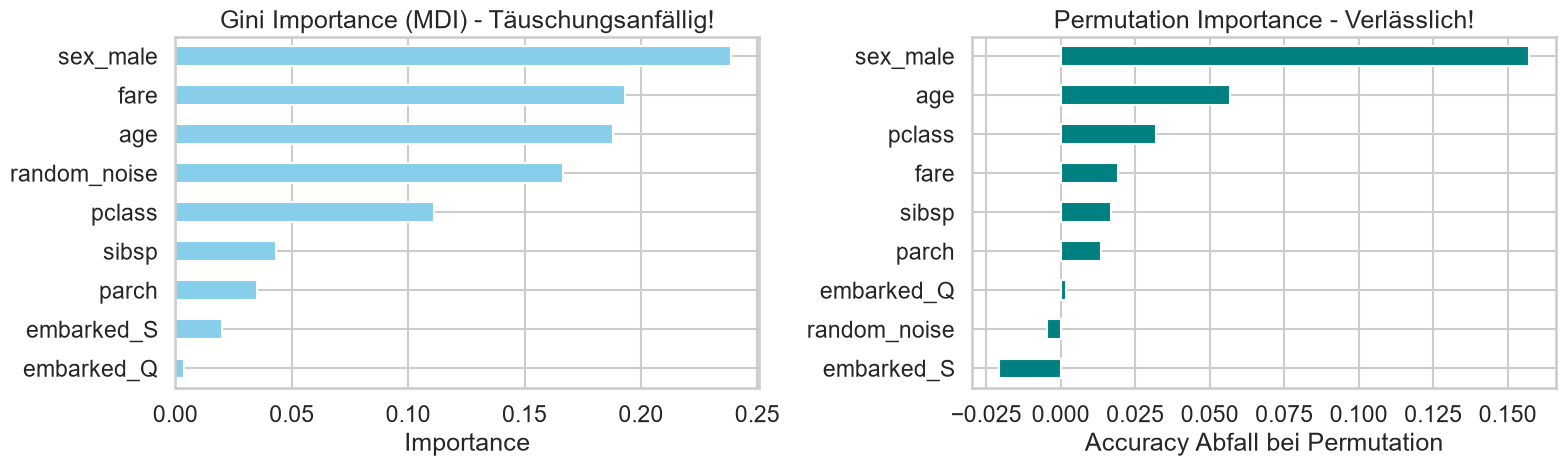

In [19]:
# Vizualisierung nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

gini_imp.sort_values().plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("Gini Importance (MDI) - Täuschungsanfällig!")
axes[0].set_xlabel("Importance")

perm_imp.sort_values().plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Permutation Importance - Verlässlich!")
axes[1].set_xlabel("Accuracy Abfall bei Permutation")

plt.tight_layout()
plt.show()

**Diskussion**:

Warum schneidet die Spalte random_noise in der Gini-Importance verhältnismäßig hoch ab, obwohl sie keinerlei Information über das Überleben enthält?

Wie funktioniert die Permutation Importance? (Tipp: Werte einer Spalte auf den Testdaten zufällig durchmischen und den Abfall der Test-Accuracy messen).

---

## 5.8 Zusammenfassung, Gesamtvergleich & Aufgaben
Modellübersicht (Lektion 4 & 5)

In [20]:
summary_data = pd.DataFrame([
{"Modell": "Decision Tree (Unpruned)", "Typ": "Einzelmodell", "Test-Acc": round(acc_tree, 3), "Hauptproblem": "Hohe Varianz, Overfitting"},
{"Modell": "Bagging Classifier", "Typ": "Ensemble", "Test-Acc": round(acc_bagging, 3), "Hauptproblem": "Korrelierte Bäume"},
{"Modell": "Random Forest", "Typ": "Ensemble", "Test-Acc": round(acc_rf, 3), "Hauptproblem": "Schwerer interpretierbar als Einzelbaum"}
])

display(summary_data)

,Modell,Typ,Test-Acc,Hauptproblem
0,Decision Tree (Unpruned),Einzelmodell,0.747,"Hohe Varianz, Overfitting"
1,Bagging Classifier,Ensemble,0.753,Korrelierte Bäume
2,Random Forest,Ensemble,0.764,Schwerer interpretierbar als Einzelbaum


### Aufgaben für Studierende

1. Parameter max_depth beim Random Forest: 
* Ändere bei RandomForestClassifier den Parameter `max_depth` (z. B. auf 2, 4, 8, None). 
* Vergleiche Train- vs. Test-Accuracy. Warum verringert ein flacher Baum im Random Forest oft die Performanz, obwohl flache Bäume bei Einzelbäumen gut gegen Overfitting helfen?

2. Extremfall `max_features=1`:
* Setze max_features=1 und erhöhe n_estimators auf 500.
* Erreicht das Modell eine gute Accuracy? Warum braucht man bei sehr kleinem max_features wesentlich mehr Bäume?

3. Vergleich mit Ridge/Lasso aus Lektion 4:
* Überlege: In welchen Szenarien (z. B. Datensätze mit sehr vielen Spalten, aber wenigen Zeilen $p \gg n$) ist eine Lasso-Regression einem Random Forest überlegen und umgekehrt?

### Fazit
* > Random Forest = Bagging + Feature Randomness ($m < p$).
    - $m$ (Sampled Features)
    - $p$ (Total Features)
* Durch die zufällige Auswahl der Merkmale pro Split werden die Bäume dekorreliert.
* Mehr Bäume führen nicht zu Overfitting – das Modell stabilisiert sich lediglich ab einer gewissen Anzahl an Bäumen (`n_estimators`).
* Der OOB-Score liefert eine kostenlose Validierungsschätzung.
* Verwende zur Interpretation bevorzugt Permutation Importance anstelle der eingebauten Gini Importance (`feature_importances_`)